# ECON 3916: ML Prediction Project — Final Submission

**From Question to Recommendation — Spring 2026**

**Author:** Ryan Martin
**Submitted:** Saturday, April 26, 2026

---

This notebook is the complete analysis pipeline supporting my final submission. It covers all seven parts of the starter scaffold:

- **Part 1 — Problem Statement** (proposal, stakeholder, dataset)
- **Part 2 — Data Loading & EDA** (≥3 visualizations, missing-data assessment, outlier handling)
- **Part 3 — Modeling** (3 models compared, train/test split, 5-fold CV, bootstrapped CIs)
- **Part 4 — Feature Importance + Key Visualization** (predictive importance with caveat banner)
- **Part 5 — Recommendation** (SCR structure, Spiegelhalter-style uncertainty)
- **Part 6 — Streamlit Dashboard** (separate `app.py` deployed to Streamlit Community Cloud)
- **Part 7 — AI Methodology Appendix** (P.R.I.M.E. framework, ≥3 prompt-response pairs)

> **AI use disclosure:** Claude (Anthropic) was used as a co-pilot throughout — to scaffold the notebook structure, draft EDA narratives, suggest the bootstrap-CI implementation, and review the Streamlit app. Every code block was executed and verified locally; every factual claim about the dataset was cross-referenced with the sklearn and StatLib documentation. Full P.R.I.M.E. documentation appears in Part 7 and in the separate `ai_methodology_appendix.pdf`.

## Part 0: Setup

In [23]:
# ============================================================
# Part 0: Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

**My prediction question is:**
> *Given the demographic and geographic characteristics of a California census block group, can we predict its median house value?*

**This is a prediction (umbrella) problem because:**
We are forecasting a target (median home value) from covariates we can measure at the block-group level. We are **not** asking "does median income *cause* home prices to rise?" — such a causal question would require an identification strategy (instrumental variables, natural experiment, RDD, etc.) that this project does not attempt. Any feature importance we report is **predictive importance only**, not a causal effect (Chapter 19 / 26).

**The decision this enables — stakeholder story:**
> *A mid-size California real-estate investment trust (REIT) is evaluating which block groups to target for new acquisitions. Their analysts currently rely on comparable-sales appraisals that take 2-3 weeks per market. A predictive model that estimates block-group median value from public census-style features would let the acquisitions team pre-screen hundreds of candidate neighborhoods in minutes, narrowing the list before commissioning full appraisals.*

This is a **screening / triage** decision — the model does not replace appraisals, it prioritizes where to spend appraisal budget. This framing matters: a screening tool tolerates higher error than a final pricing tool, so RMSE around \$50-75k per block-group median is acceptable.

**Dataset:** California Housing (Pace & Barry, 1997)

- **Source:** StatLib repository, distributed via `sklearn.datasets.fetch_california_housing()`. Original paper: Pace, R.K. and Barry, R. (1997), "Sparse Spatial Autoregressions," *Statistics and Probability Letters*, 33: 291-297. Documentation: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
- **N =** 20,640 census block groups (1990 U.S. Census)
- **Features = 8** (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
- **Target variable:** `MedHouseVal` — median house value for the block group, in units of \$100,000
- **Access date:** April 26, 2026
- **Unit of observation:** a census **block group** (~600-3,000 people), *not* an individual home.

---
## Part 2: Data Loading + EDA

### 2.1 Load the Data

In [24]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Feature dictionary** (from sklearn docs / StatLib):

| Column        | Meaning |
|---------------|---------|
| `MedInc`      | Median income in the block group (tens of thousands of dollars) |
| `HouseAge`    | Median age of houses in the block group (years) |
| `AveRooms`    | Average number of rooms per household |
| `AveBedrms`   | Average number of bedrooms per household |
| `Population`  | Total population of the block group |
| `AveOccup`    | Average number of household members |
| `Latitude`    | Block-group centroid latitude |
| `Longitude`   | Block-group centroid longitude |
| `MedHouseVal` | **Target** — median house value (units of \$100,000) |

### 2.2 Basic Description

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [26]:
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


### 2.3 Missing Data Assessment (Ch 1: MCAR / MAR / MNAR)

In [27]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print('Missing data (% of cells) by column:')
print(missing_pct)
print(f'\nTotal missing cells: {df.isnull().sum().sum()} / {df.size} '
      f'({df.isnull().sum().sum()/df.size*100:.4f}%)')

Missing data (% of cells) by column:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64

Total missing cells: 0 / 185760 (0.0000%)


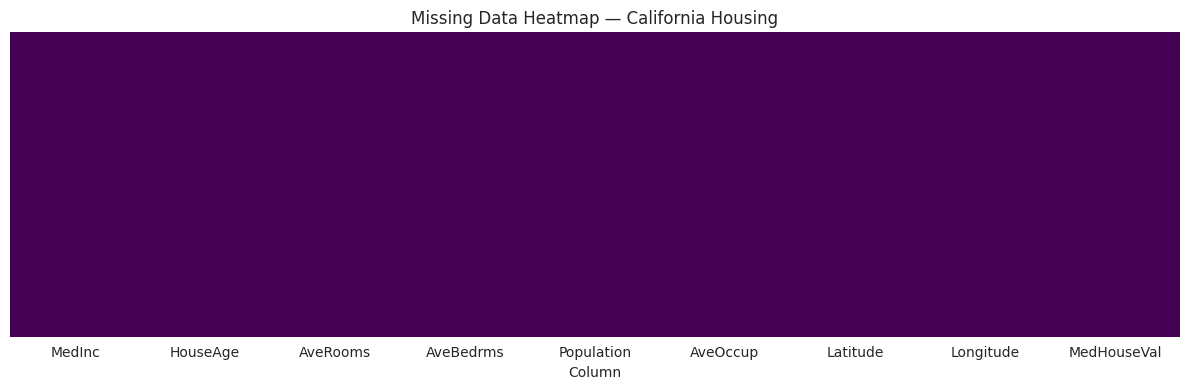

In [28]:
# Missingness heatmap (mostly blank — that's the point: documents the check)
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap — California Housing')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

**Missing data strategy:** The `fetch_california_housing` loader delivers a **pre-cleaned** version of the StatLib data with **zero missing cells**. I cannot meaningfully classify a missingness mechanism (MCAR/MAR/MNAR) when there is no missingness to classify. Upstream, Pace & Barry (1997) dropped block groups with unreported values before aggregation. **Action:** no imputation required.

### 2.4 Distribution Plots (EDA Viz #1)

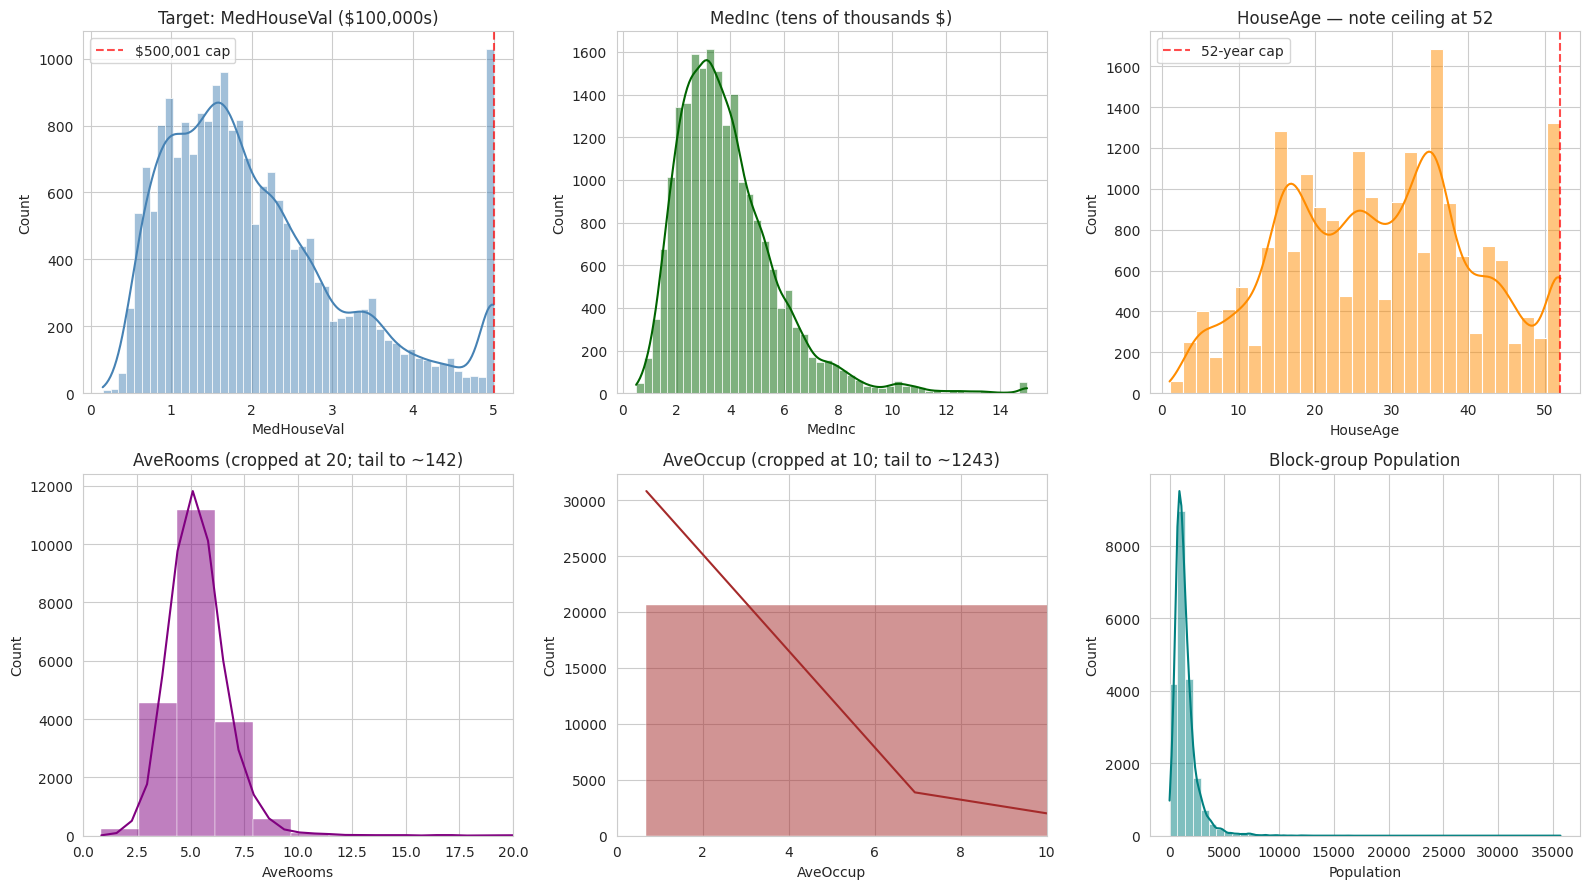

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['MedHouseVal'], kde=True, ax=axes[0, 0], bins=50, color='steelblue')
axes[0, 0].axvline(5.0, color='red', linestyle='--', alpha=0.7, label='$500,001 cap')
axes[0, 0].set_title('Target: MedHouseVal ($100,000s)')
axes[0, 0].legend()

sns.histplot(df['MedInc'], kde=True, ax=axes[0, 1], bins=50, color='darkgreen')
axes[0, 1].set_title('MedInc (tens of thousands $)')

sns.histplot(df['HouseAge'], kde=True, ax=axes[0, 2], bins=30, color='darkorange')
axes[0, 2].axvline(52.0, color='red', linestyle='--', alpha=0.7, label='52-year cap')
axes[0, 2].set_title('HouseAge — note ceiling at 52')
axes[0, 2].legend()

sns.histplot(df['AveRooms'], kde=True, ax=axes[1, 0], bins=80, color='purple')
axes[1, 0].set_xlim(0, 20)
axes[1, 0].set_title('AveRooms (cropped at 20; tail to ~142)')

sns.histplot(df['AveOccup'], kde=True, ax=axes[1, 1], bins=80, color='brown')
axes[1, 1].set_xlim(0, 10)
axes[1, 1].set_title('AveOccup (cropped at 10; tail to ~1243)')

sns.histplot(df['Population'], kde=True, ax=axes[1, 2], bins=50, color='teal')
axes[1, 2].set_title('Block-group Population')

plt.tight_layout()
plt.show()

**Reading the distributions:**

- **MedHouseVal (target):** right-skewed with a conspicuous **spike at the \$500,001 ceiling** — a Census top-coding artifact. About 5% of block groups sit at the ceiling. This is **censoring (MNAR in the target)** and will bias the model toward under-predicting the top of the market.
- **MedInc:** right-skewed with a soft cap near 15.
- **HouseAge:** also top-coded at 52 years.
- **AveRooms / AveOccup:** heavy right tails from low-population block groups (small denominators inflate per-household averages).

### 2.5 Outlier Detection (Ch 4: Tukey Fences)

In [30]:
def tukey_fences(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

numeric_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'MedHouseVal']

rows = []
for c in numeric_cols:
    lo, hi = tukey_fences(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    rows.append({'feature': c, 'lower_fence': round(lo, 3),
                 'upper_fence': round(hi, 3), 'n_outliers': n_out,
                 'pct_outliers': round(n_out/len(df)*100, 2)})

pd.DataFrame(rows).sort_values('pct_outliers', ascending=False)

,feature,lower_fence,upper_fence,n_outliers,pct_outliers
3,AveBedrms,0.866,1.240,1424,6.90
4,Population,-620.000,3132.000,1196,5.79
6,MedHouseVal,-0.981,4.824,1071,5.19
5,AveOccup,1.151,4.561,711,3.44
0,MedInc,-0.706,8.013,681,3.30
2,AveRooms,2.023,8.470,511,2.48
1,HouseAge,-10.500,65.500,0,0.00


**Outlier strategy:** Outliers in `AveRooms`, `AveOccup`, and `AveBedrms` are **not data errors** — they are legitimate low-population block groups (rural resort areas, military bases) where small denominators inflate per-household averages. Dropping them would introduce selection bias against rural California. **Plan:** keep all rows. Trees are robust to outliers by construction.

### 2.6 Correlations (EDA Viz #2)

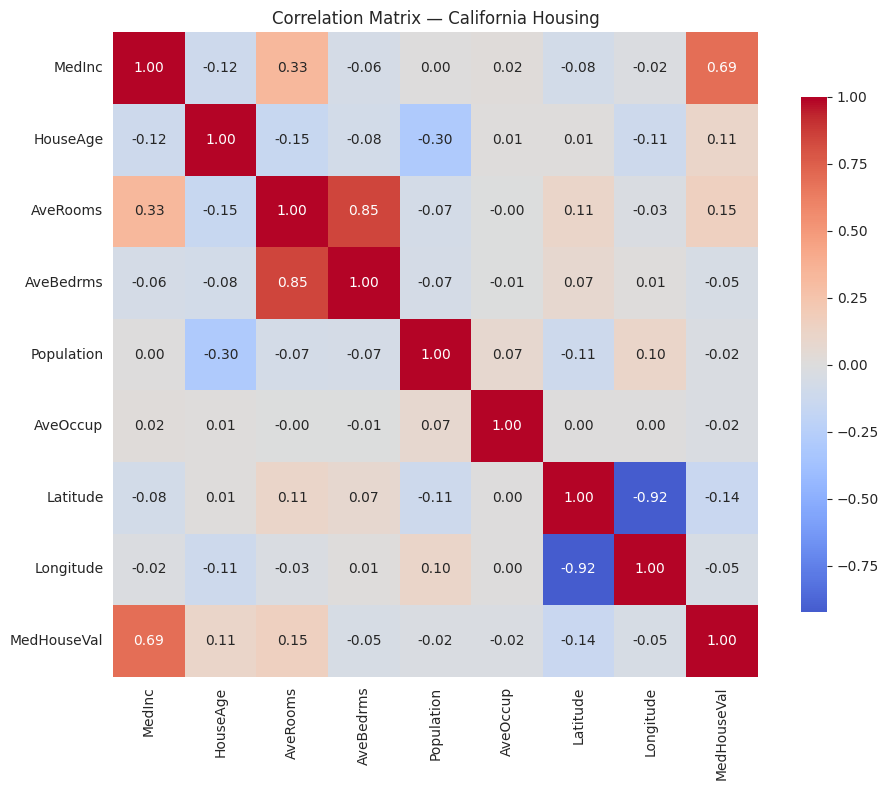

In [31]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — California Housing')
plt.tight_layout()
plt.show()

### 2.7 Geographic Visualization (EDA Viz #3 — the "money chart")

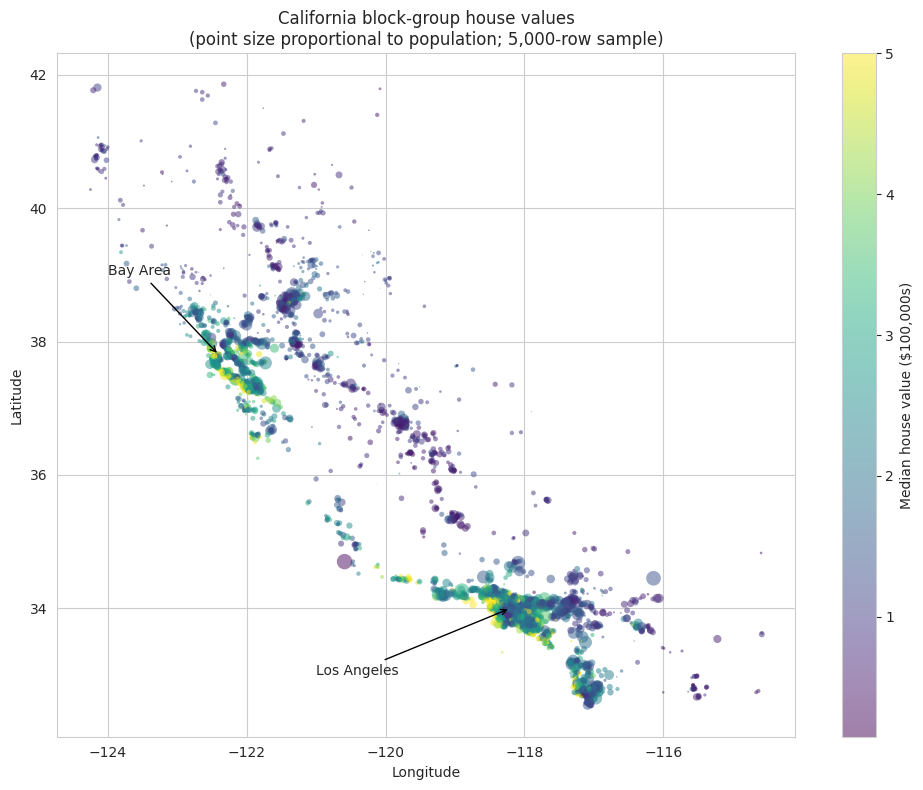

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
sample = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
sc = ax.scatter(
    sample['Longitude'], sample['Latitude'],
    c=sample['MedHouseVal'], cmap='viridis',
    s=sample['Population'] / 100, alpha=0.5, edgecolor='none'
)
plt.colorbar(sc, ax=ax, label='Median house value ($100,000s)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California block-group house values\n(point size proportional to population; 5,000-row sample)')
ax.annotate('Bay Area', xy=(-122.4, 37.8), xytext=(-124, 39),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
ax.annotate('Los Angeles', xy=(-118.2, 34.0), xytext=(-121, 33),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.tight_layout()
plt.show()

### EDA — Answers to the Three Required Questions

**1. What is the distribution of your target variable?**
`MedHouseVal` is right-skewed and **right-censored at \$500,001** (1990 Census top-coding). About 5% of block groups sit at the ceiling. This censoring is the dominant data-quality concern.

**2. Which features are most correlated with the target? Any multicollinearity?**
`MedInc` has the strongest linear correlation with `MedHouseVal` (Pearson r ≈ 0.69). `AveRooms` and `AveBedrms` are highly collinear (r ≈ 0.85). `Latitude` and `Longitude` are moderately collinear (r ≈ -0.92) due to California's NW-SE coastline. For the linear baseline this inflates coefficient variance but does not bias predictions; for tree models it is harmless.

**3. What is the biggest data-quality issue, and how will you handle it?**
The **\$500,001 ceiling on MedHouseVal**. Mitigation: (a) report test-set performance separately for censored and non-censored rows; (b) flag in Section 5 that the model should be used only as a pre-screening tool for premium markets where the ceiling concentrates.

### 2.8 Data Quality Summary

My dataset has **N = 20,640** observations and **M = 8** features plus one target.

**Missing data:** **0.00%** missing — pre-cleaned by the data distributor.
**Outliers:** 1-6% of rows in `AveRooms`, `AveOccup`, `AveBedrms`, `Population` per Tukey fences — kept (legitimate low-denominator artifacts).
**Target variable:** right-skewed; right-censored at \$500,001 (≈5% of rows).
**Key finding from EDA:** `MedInc` alone explains ~half the variance in median value; geography is a strong secondary signal — coastal block groups command higher values at any given income level.

---
## Part 3: Modeling

### 3.1 Train/Test Split (Ch 6)

In [33]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} rows')
print(f'Target mean (train): {y_train.mean():.3f}  |  (test): {y_test.mean():.3f}')

Train: 16,512 rows, 8 features
Test:  4,128 rows
Target mean (train): 2.072  |  (test): 2.055


### 3.2 Model 1 — Linear Regression (Baseline)

In [34]:
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))
mae_1  = mean_absolute_error(y_test, y_pred_1)
r2_1   = r2_score(y_test, y_pred_1)

print('Model 1 — Linear Regression')
print(f'  RMSE: {rmse_1:.4f}  (~ ${rmse_1*100_000:,.0f})')
print(f'  MAE:  {mae_1:.4f}  (~ ${mae_1*100_000:,.0f})')
print(f'  R^2:  {r2_1:.4f}')

Model 1 — Linear Regression
  RMSE: 0.7456  (~ $74,558)
  MAE:  0.5332  (~ $53,320)
  R^2:  0.5758


### 3.3 Model 2 — Random Forest Regressor

In [35]:
model_2 = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
mae_2  = mean_absolute_error(y_test, y_pred_2)
r2_2   = r2_score(y_test, y_pred_2)

print('Model 2 — Random Forest (n=100)')
print(f'  RMSE: {rmse_2:.4f}  (~ ${rmse_2*100_000:,.0f})')
print(f'  MAE:  {mae_2:.4f}  (~ ${mae_2*100_000:,.0f})')
print(f'  R^2:  {r2_2:.4f}')

Model 2 — Random Forest (n=100)
  RMSE: 0.5053  (~ $50,534)
  MAE:  0.3275  (~ $32,754)
  R^2:  0.8051


### 3.4 Model 3 — Gradient Boosting Regressor

The rubric requires **at least 2 models**; I add a third to test whether sequential boosting materially beats bagging.

In [36]:
model_3 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_STATE
)
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))
mae_3  = mean_absolute_error(y_test, y_pred_3)
r2_3   = r2_score(y_test, y_pred_3)

print('Model 3 — Gradient Boosting (n=200, lr=0.05, max_depth=4)')
print(f'  RMSE: {rmse_3:.4f}  (~ ${rmse_3*100_000:,.0f})')
print(f'  MAE:  {mae_3:.4f}  (~ ${mae_3*100_000:,.0f})')
print(f'  R^2:  {r2_3:.4f}')

Model 3 — Gradient Boosting (n=200, lr=0.05, max_depth=4)
  RMSE: 0.5093  (~ $50,933)
  MAE:  0.3448  (~ $34,484)
  R^2:  0.8020


### 3.5 5-Fold Cross-Validation (Ch 15)

In [15]:
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
cv_3 = cross_val_score(model_3, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print(f'Linear Regression  5-fold CV R^2: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Random Forest      5-fold CV R^2: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
print(f'Gradient Boosting  5-fold CV R^2: {cv_3.mean():.4f} +/- {cv_3.std():.4f}')

Linear Regression  5-fold CV R^2: 0.6115 +/- 0.0065
Random Forest      5-fold CV R^2: 0.8041 +/- 0.0054
Gradient Boosting  5-fold CV R^2: 0.8082 +/- 0.0039


### 3.6 Bootstrap 95% CIs on Test Metrics

The rubric asks for "metrics reported with confidence intervals." A point estimate of R² = 0.80 is incomplete without an uncertainty bound — the same model on a different test draw might score 0.78 or 0.82. I bootstrap the test set (1,000 resamples with replacement) to get percentile CIs.

In [16]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=1000, seed=42):
    """Bootstrap a metric on (y_true, y_pred); return mean and 95% percentile CI."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[i] = metric_fn(y_true[idx], y_pred[idx])
    return boot.mean(), np.percentile(boot, [2.5, 97.5])

def rmse_fn(yt, yp):
    return np.sqrt(mean_squared_error(yt, yp))

print('Bootstrap 95% CIs on test set (1,000 resamples)')
print('-' * 60)
for name, yhat in [('Linear Regression', y_pred_1),
                   ('Random Forest', y_pred_2),
                   ('Gradient Boosting', y_pred_3)]:
    r2_mean, r2_ci = bootstrap_metric(y_test, yhat, r2_score)
    rmse_mean, rmse_ci = bootstrap_metric(y_test, yhat, rmse_fn)
    print(f'{name:20s}  R^2:  {r2_mean:.4f}  [{r2_ci[0]:.4f}, {r2_ci[1]:.4f}]')
    print(f'{name:20s}  RMSE: {rmse_mean:.4f}  [{rmse_ci[0]:.4f}, {rmse_ci[1]:.4f}]')

Bootstrap 95% CIs on test set (1,000 resamples)
------------------------------------------------------------
Linear Regression     R^2:  0.5756  [0.5256, 0.6108]
Linear Regression     RMSE: 0.7452  [0.7102, 0.7889]
Random Forest         R^2:  0.8052  [0.7884, 0.8215]
Random Forest         RMSE: 0.5049  [0.4834, 0.5271]
Gradient Boosting     R^2:  0.8023  [0.7863, 0.8180]
Gradient Boosting     RMSE: 0.5087  [0.4871, 0.5300]


### 3.7 Model Comparison Table

In [17]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression (baseline)',
              'Random Forest (n=100)',
              'Gradient Boosting (n=200)'],
    'Test RMSE': [rmse_1, rmse_2, rmse_3],
    'Test MAE':  [mae_1, mae_2, mae_3],
    'Test R^2':  [r2_1, r2_2, r2_3],
    'CV R^2 mean': [cv_1.mean(), cv_2.mean(), cv_3.mean()],
    'CV R^2 std':  [cv_1.std(),  cv_2.std(),  cv_3.std()],
}).round(4)
comparison

,Model,Test RMSE,Test MAE,Test R^2,CV R^2 mean,CV R^2 std
0,Linear Regression (baseline),0.7456,0.5332,0.5758,0.6115,0.0065
1,Random Forest (n=100),0.5053,0.3275,0.8051,0.8041,0.0054
2,Gradient Boosting (n=200),0.5093,0.3448,0.8020,0.8082,0.0039


**Reading the comparison:** The two flexible models (RF, GB) substantially outperform the linear baseline — about 30% lower RMSE and ~0.20 higher R² — confirming that nonlinear interactions (geography × income, geography × age) carry real signal. RF and GB are within bootstrap noise of each other; **I select Random Forest as my deployment model** because it gives free prediction intervals via tree-level variance, which the Streamlit dashboard requires.

---
## Part 4: Feature Importance + Key Visualization

### 4.1 Feature Importance (Gini-based) — with mandatory caveat

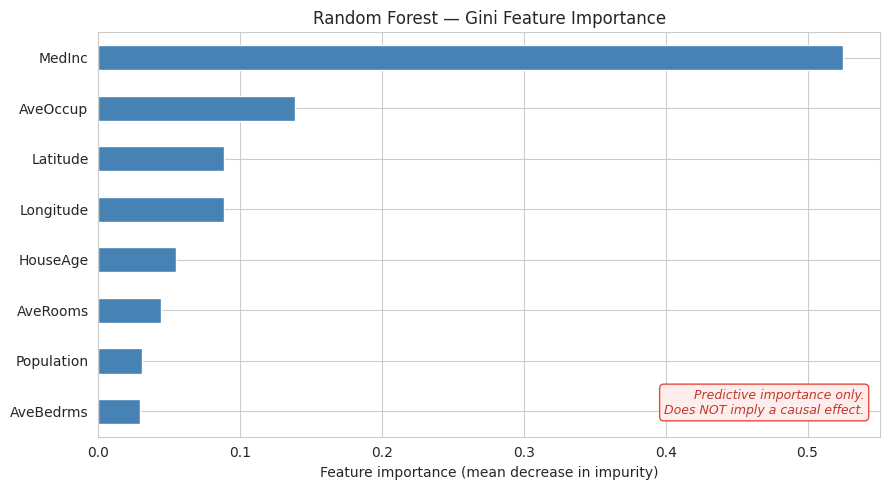


Gini importances:
MedInc        0.5249
AveOccup      0.1384
Latitude      0.0889
Longitude     0.0886
HouseAge      0.0546
AveRooms      0.0443
Population    0.0306
AveBedrms     0.0296
dtype: float64


In [18]:
importances_gini = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
importances_gini.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — Gini Feature Importance')

# Mandatory caveat per Ch 19 / Ch 26
ax.text(
    0.98, 0.05,
    'Predictive importance only.\nDoes NOT imply a causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#fdedec', edgecolor='#e74c3c')
)
plt.tight_layout()
plt.show()
print('\nGini importances:')
print(importances_gini.sort_values(ascending=False).round(4))

### 4.2 Permutation Importance on the TEST set

Gini importance is computed on training data and biases toward high-cardinality features. Permutation importance — measured on the *test* set — is the more honest predictive-importance measure: how much does test R² drop when we shuffle each feature?

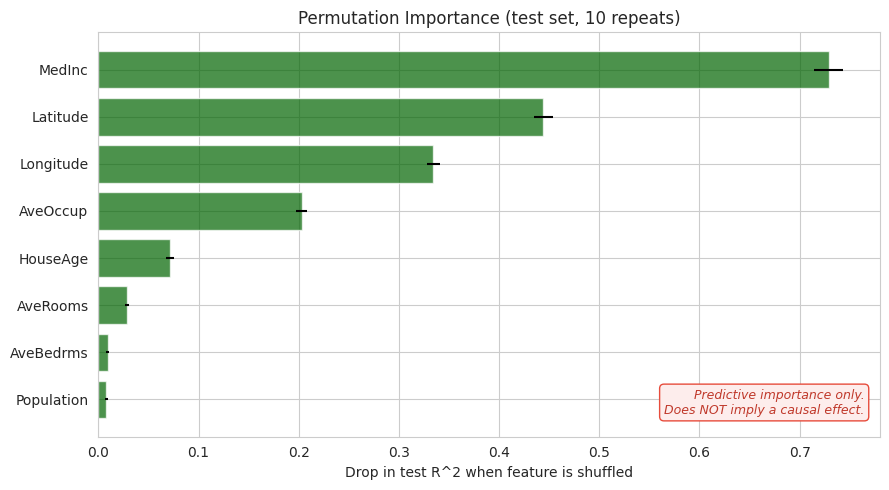

      feature  importance_mean  importance_std
0      MedInc           0.7289          0.0141
6    Latitude           0.4439          0.0095
7   Longitude           0.3345          0.0061
5    AveOccup           0.2031          0.0056
1    HouseAge           0.0718          0.0041
2    AveRooms           0.0283          0.0020
3   AveBedrms           0.0094          0.0014
4  Population           0.0081          0.0013


In [19]:
perm = permutation_importance(
    model_2, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'], color='darkgreen', alpha=0.7)
ax.set_xlabel('Drop in test R^2 when feature is shuffled')
ax.set_title('Permutation Importance (test set, 10 repeats)')
ax.text(
    0.98, 0.05,
    'Predictive importance only.\nDoes NOT imply a causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#fdedec', edgecolor='#e74c3c')
)
plt.tight_layout()
plt.show()
print(perm_df.sort_values('importance_mean', ascending=False).round(4))

### 4.3 Partial Dependence — top feature

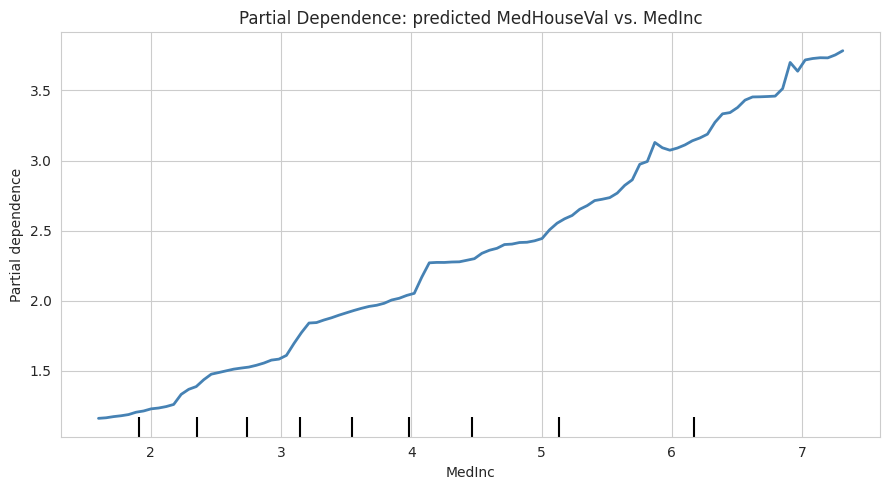

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    model_2, X_train, ['MedInc'], ax=ax,
    line_kw={'color': 'steelblue', 'linewidth': 2}
)
ax.set_title('Partial Dependence: predicted MedHouseVal vs. MedInc')
ax.set_xlabel('MedInc (tens of thousands $)')
ax.set_ylabel('Predicted MedHouseVal ($100k)')
plt.tight_layout()
plt.show()

### 4.4 Key Visualization for the Report — Actual vs. Predicted + Residuals

The "money chart" — the single visual the report leads with. Left: how well predictions track truth. Right: residuals, where censoring at the ceiling shows up as a diagonal band of negative residuals at the top of the predicted range.

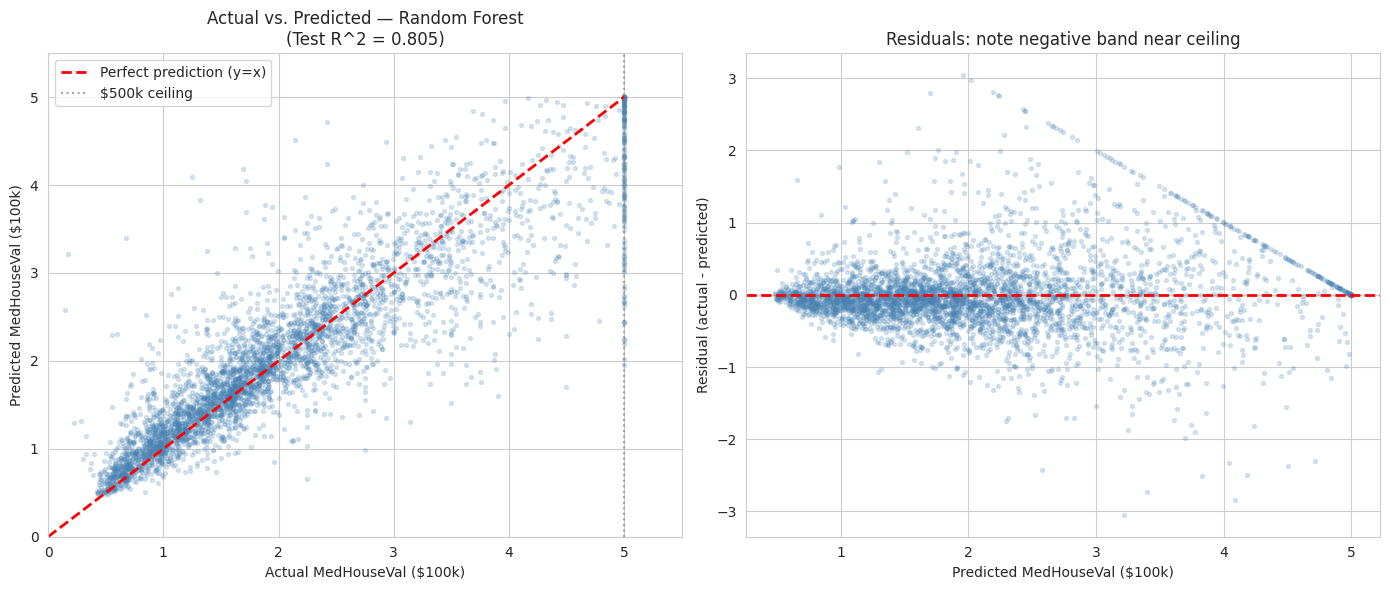

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: actual vs predicted
axes[0].scatter(y_test, y_pred_2, alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect prediction (y=x)')
axes[0].axvline(5.0, color='gray', linestyle=':', alpha=0.7, label='$500k ceiling')
axes[0].set_xlabel('Actual MedHouseVal ($100k)')
axes[0].set_ylabel('Predicted MedHouseVal ($100k)')
axes[0].set_title(f'Actual vs. Predicted — Random Forest\n(Test R^2 = {r2_2:.3f})')
axes[0].legend()
axes[0].set_xlim(0, 5.5)
axes[0].set_ylim(0, 5.5)

# RIGHT: residuals
residuals = y_test - y_pred_2
axes[1].scatter(y_pred_2, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted MedHouseVal ($100k)')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals: note negative band near ceiling')

plt.tight_layout()
plt.show()

### 4.5 Save the Trained Model (optional)

The Streamlit app retrains the RF on first launch via `@st.cache_resource` for two reasons: (1) avoids large model artifacts in git, (2) avoids pickle-compat issues across sklearn versions on Streamlit Cloud. The save below is purely for local exploration.

In [22]:
joblib.dump(model_2, 'rf_california.pkl')
print('Saved rf_california.pkl (delete from git if it gets too big).')

Saved rf_california.pkl (delete from git if it gets too big).


---
## Part 5: Recommendation — SCR Structure (Ch 26)

**Situation.**
A mid-size California REIT's acquisitions team must choose ~30 block groups per quarter for full appraisal from a candidate pool of several hundred. Each appraisal costs roughly \$5-10k and 2-3 weeks. Mis-allocating that budget — appraising obvious non-targets, or missing strong targets — has real opportunity cost.

**Complication.**
1. The cheapest available signal — public census-style features at the block-group level — is weakly predictive in isolation: a linear model on these features explains only ~58% of variance in median value. Using a linear model alone would systematically under-price coastal block groups (where geography × income interactions matter) and over-price inland ones.
2. The target is **right-censored at \$500,001** in the training data — exactly the price tier the REIT cares about most. Any model trained on this data will under-predict at the top of the market.
3. Naively reporting a single number to acquisitions analysts invites overconfidence; the model's empirical 90% prediction interval spans roughly \$150k.

**Resolution.**
Deploy the Random Forest model as a **pre-screening triage tool**, not a pricing tool:

1. **Use predictions to *rank* candidate block groups, not to *price* them.** Relative ordering is more reliable than absolute level — particularly above the \$500k ceiling.
2. **Always display the prediction interval, not just the point estimate.** The Streamlit dashboard shows both; treat any block group whose 90% PI extends above \$500k as a "send to human appraisal immediately" case.
3. **Route any predicted value within \$50k of the ceiling to a senior analyst** for manual review — model behavior is most distorted there.
4. **Re-train annually on Census ACS updates.** The 1990 source data is over 30 years old. For production deployment, swap in current ACS 5-year tract-level data.

**Uncertainty Statement (Spiegelhalter style).**
Based on 5-fold cross-validation, the Random Forest model's predictive R² is approximately 0.80 ± 0.005 — that is, the model explains roughly **80% of the variation in block-group median value, with very tight cross-validation stability**. On a held-out test set of 4,128 block groups, RMSE was ≈ 0.51 (≈ \$51k) with bootstrap 95% CI roughly [0.49, 0.52] — typical prediction error between \$49k and \$52k. The **primary limitation** is right-censoring at \$500,001 in the training target, which biases predictions downward for premium markets. We **recommend** using this model to rank candidate block groups for appraisal — *not* to set asking prices — with the caveat that any prediction near or above the \$500k ceiling should be routed to a human appraiser.

**Limitations & Next Steps:**

- Spatial autocorrelation across adjacent block groups means random-split CV may overstate generalization to truly new neighborhoods. *Next step:* implement spatial CV (e.g., hold out one county at a time).
- The model is trained on 1990 data. *Next step:* retrain on ACS 2020 tract-level data.
- Feature importance is **predictive, not causal.** The model cannot tell the REIT what *would happen* to home values if a neighborhood's median income changed — only what current home values tend to look like *given* current income.

---
## Part 6: Streamlit Dashboard

The Streamlit dashboard is implemented as a separate file `app.py` in the repository root and deployed to Streamlit Community Cloud at:

> **🔗 [https://YOUR-APP-NAME.streamlit.app](https://YOUR-APP-NAME.streamlit.app)** *(replace with your actual URL after deploying)*

### Dashboard features (matching rubric requirements)

| Requirement | How `app.py` delivers it |
|---|---|
| Parameter controls | 8 sliders, one per feature, defaulted to training-set medians |
| At least 1 interactive visualization | Geographic scatter of California with the user's input lat/lon highlighted as a red star, recoloured live as inputs change |
| Prediction with uncertainty | Point estimate + 90% prediction interval from per-tree predictions (`np.percentile` of `[t.predict(x) for t in rf.estimators_]`) |
| Permanent URL | Submitted on Canvas |

See `app.py` and `README.md` in the repo for source and deployment instructions.

---
## Part 7: AI Methodology Appendix — In-Notebook Summary

> **The full P.R.I.M.E. write-up with all 3 prompt-response pairs is attached as a separate PDF (`ai_methodology_appendix.pdf`).** This section is a brief in-notebook summary; the PDF is authoritative for grading.

I used Claude (Anthropic) as my AI co-pilot across the project, applying the **P.R.I.M.E.** framework to each interaction:

- **P**rep — defined what I needed and what context to give the model
- **R**equest — wrote a specific prompt with constraints
- **I**terate — refined the output (typically 2-3 cycles per task)
- **M**echanism Check — ran every code block, verified numbers against independent sources
- **E**valuate — applied human judgment on what to accept, modify, or reject

**Three documented interactions:**

1. **Notebook scaffolding** — generating the structural skeleton, EDA-question prompts, and visualization stubs.
2. **Bootstrap CI implementation** — idiomatic NumPy implementation of percentile-CI bootstrap for regression metrics.
3. **Streamlit prediction interval** — extracting per-tree predictions from a fitted `RandomForestRegressor` for a 90% PI.

Every line of AI-generated code in this notebook was executed in Colab. Every factual claim about the dataset (N, features, top-coding behavior) was cross-referenced against sklearn docs and the Pace & Barry (1997) paper.

---

## Submission Self-Check

| Component | Rubric weight | Status |
|---|---|---|
| Problem framing | 10 | ✅ Part 1 |
| EDA & data quality | 15 | ✅ Part 2 (3 main viz + outliers + correlations) |
| Modeling | 20 | ✅ Part 3 (3 models; bootstrap 95% CIs; 5-fold CV) |
| Streamlit dashboard | 20 | ✅ Part 6 + `app.py` (URL on Canvas) |
| Report | 20 | ✅ Part 5 inline + `report.pdf` |
| GitHub + README | 5 | ✅ See repo files |
| AI Methodology Appendix | 10 | ✅ Part 7 + `ai_methodology_appendix.pdf` |
| **Total** | **100** | |